# DBSCAN Demo

This notebook runs the custom `DBSCAN` implementation on the public Iris dataset, then compares it with scikit-learn's `DBSCAN`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd()
if not (project_root / "src" / "dbscan.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dbscan import DBSCAN

In [2]:
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

eps = 0.8
min_samples = 3

In [3]:
custom_model = DBSCAN(eps=eps, min_samples=min_samples)
custom_labels = custom_model.fit_predict(X_scaled)

custom_cluster_labels = sorted(label for label in set(custom_labels) if label != -1)
custom_noise_count = np.sum(custom_labels == -1)

print("custom clusters:", custom_cluster_labels)
print("custom cluster sizes:", {label: np.sum(custom_labels == label) for label in custom_cluster_labels})
print("custom noise points:", custom_noise_count)

custom clusters: [0, 1]
custom cluster sizes: {0: 49, 1: 97}
custom noise points: 4


In [4]:
sklearn_model = SklearnDBSCAN(eps=eps, min_samples=min_samples)
sklearn_labels = sklearn_model.fit_predict(X_scaled)

sklearn_cluster_labels = sorted(label for label in set(sklearn_labels) if label != -1)
sklearn_noise_count = np.sum(sklearn_labels == -1)

print("sklearn clusters:", sklearn_cluster_labels)
print("sklearn cluster sizes:", {label: np.sum(sklearn_labels == label) for label in sklearn_cluster_labels})
print("sklearn noise points:", sklearn_noise_count)

sklearn clusters: [0, 1]
sklearn cluster sizes: {0: 49, 1: 97}
sklearn noise points: 4


## Result comparison

In [5]:
label_agreement = adjusted_rand_score(custom_labels, sklearn_labels)

print(f"custom number of clusters: {len(custom_cluster_labels)}")
print(f"sklearn number of clusters: {len(sklearn_cluster_labels)}")
print(f"custom noise points: {custom_noise_count}")
print(f"sklearn noise points: {sklearn_noise_count}")
print(f"adjusted Rand index: {label_agreement:.4f}")

custom number of clusters: 2
sklearn number of clusters: 2
custom noise points: 4
sklearn noise points: 4
adjusted Rand index: 1.0000


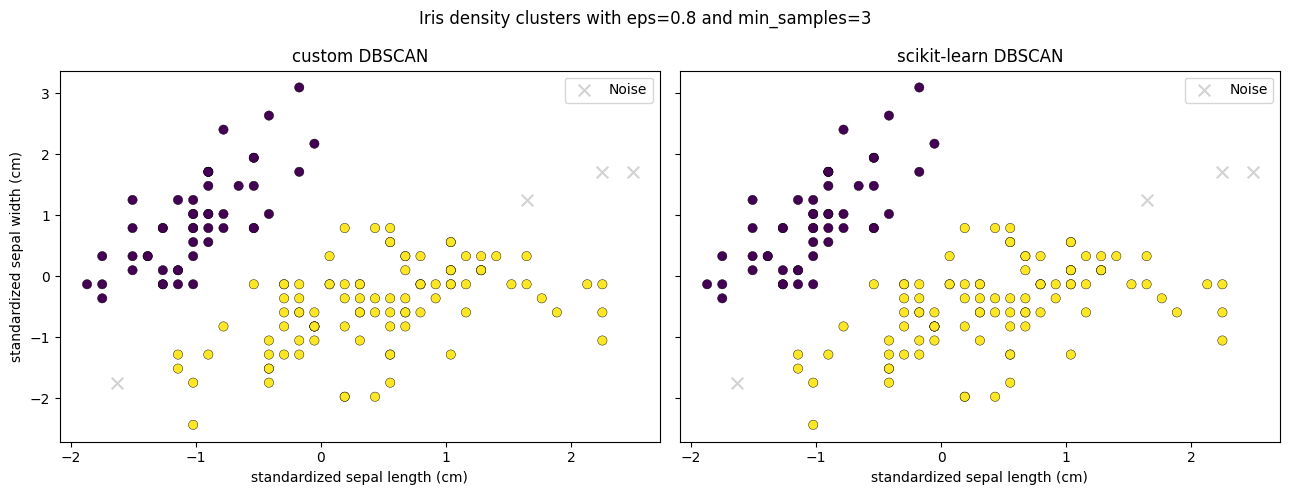

In [6]:
def plot_result(ax, labels, title):
    cluster_mask = labels != -1
    noise_mask = labels == -1

    scatter = ax.scatter(
        X_scaled[cluster_mask, 0],
        X_scaled[cluster_mask, 1],
        c=labels[cluster_mask],
        cmap="viridis",
        s=45,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.scatter(
        X_scaled[noise_mask, 0],
        X_scaled[noise_mask, 1],
        c="lightgray",
        marker="x",
        s=70,
        label="Noise",
    )
    ax.set_title(title)
    ax.set_xlabel(f"standardized {feature_names[0]}")
    ax.legend(loc="best")
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

plot_result(axes[0], custom_labels, "custom DBSCAN")
axes[0].set_ylabel(f"standardized {feature_names[1]}")

plot_result(axes[1], sklearn_labels, "scikit-learn DBSCAN")

plt.suptitle(f"Iris density clusters with eps={eps} and min_samples={min_samples}")
plt.tight_layout()
plt.show()